In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🛒 E-Commerce Business Performance Analysis

## 🎯 Objective
Analyse business performance using profit trends, customer insights, and sales targets.


In [116]:
orders = pd.read_excel(
    "../data/Worksheet in E-Commerce _Command Center (1).xlsm",
    sheet_name="List of Orders"
)

order_details = pd.read_excel(
    "../data/Worksheet in E-Commerce _Command Center (2).xlsm"
)

sales_target = pd.read_excel(
    "../data/Worksheet in E-Commerce _Command Center (3).xlsm"
)

## 🔍 Data Understanding
Checking structure and columns of datasets.

In [117]:
orders.head()
order_details.head()
sales_target.head()

,Month of Order Date,Category,Target
0,2022-04-18,Furniture,10400
1,2022-05-18,Furniture,10500
2,2022-06-18,Furniture,10600
3,2022-07-18,Furniture,10800
4,2022-08-18,Furniture,10900


##  Data Cleaning & Preprocessing
- Converted date columns
- Created month column
- Merged datasets

In [118]:
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Month'] = orders['Order Date'].dt.to_period('M').astype(str)

sales_target['Month'] = pd.to_datetime(
    sales_target['Month of Order Date']
).dt.to_period('M').astype(str)

merged_df = pd.merge(order_details, orders, on='Order ID', how='inner')

## 🌍 Profit by State

This analysis shows how profit is distributed across different states.

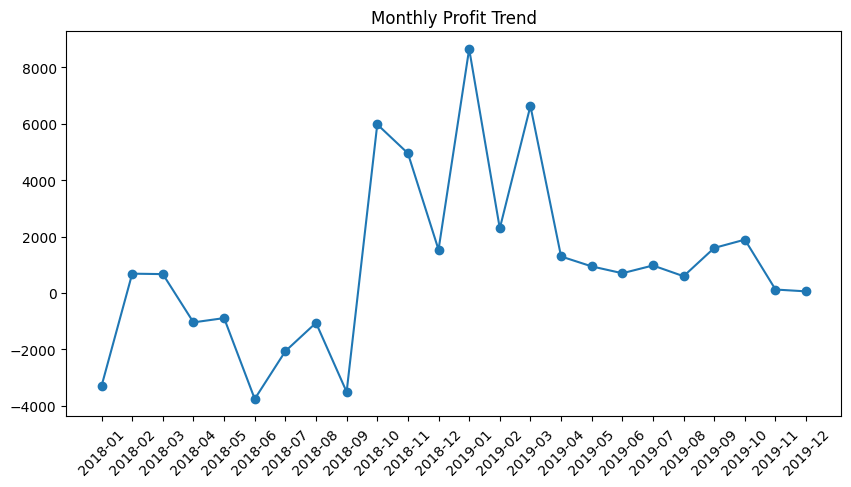

In [119]:
monthly_profit = merged_df.groupby('Month')['Profit'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_profit['Month'], monthly_profit['Profit'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Profit Trend")
plt.show()

### 💡 Insight:
- Profit distribution is uneven across states
- A few states contribute significantly higher revenue
- High-performing regions should be prioritised for expansion

## 👤 Customer Analysis

Identifying top customers contributing to profit.

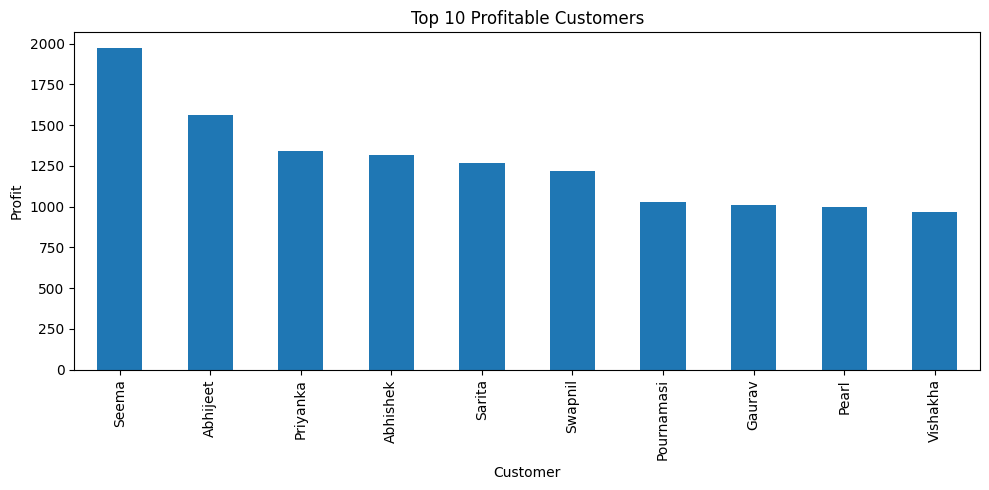

In [120]:
top_customers = (
    merged_df.groupby('CustomerName')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title("Top 10 Profitable Customers")
plt.xlabel("Customer")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### 💡 Insight:
- A small number of customers contribute most of the profit
- These high-value customers should be retained and targeted
- Over-dependence on few customers may be risky

## 🛍️ Category Contribution

Understanding which product categories contribute most to profit.

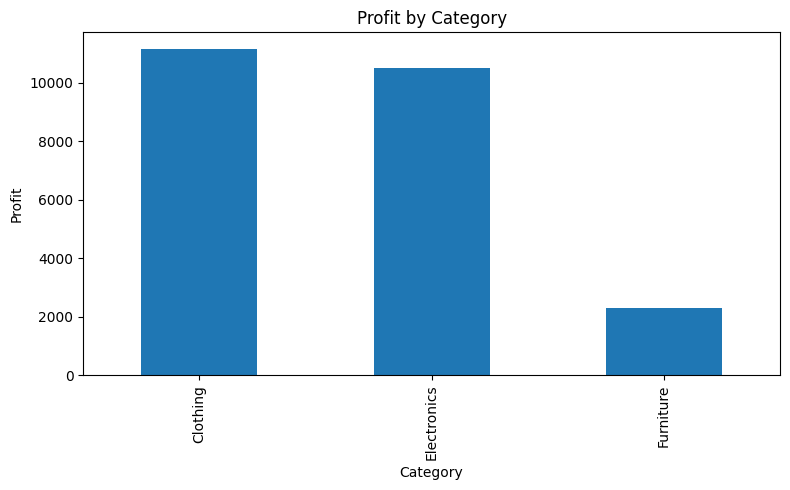

In [121]:
category_profit = merged_df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### 💡 Insight:
- Some categories dominate profit contribution
- Low-performing categories need improvement strategies
- Optimising product portfolio can increase profitability

## 🎯 Sales Target Analysis

Comparing actual profit with sales targets across categories and months.

In [122]:
actual_profit = (
    merged_df.groupby(['Category', 'Month'])['Profit']
    .sum()
    .reset_index()
)

actual_profit.head()

,Category,Month,Profit
0,Clothing,2018-01,-602
1,Clothing,2018-02,51
2,Clothing,2018-03,39
3,Clothing,2018-04,429
4,Clothing,2018-05,300


In [123]:
# Convert both to datetime
actual_profit['Month'] = pd.to_datetime(actual_profit['Month'])
sales_target['Month'] = pd.to_datetime(sales_target['Month'])

# Extract month number
actual_profit['Month'] = actual_profit['Month'].dt.month
sales_target['Month'] = sales_target['Month'].dt.month

In [124]:
actual_profit['Category'] = actual_profit['Category'].str.strip().str.lower()
sales_target['Category'] = sales_target['Category'].str.strip().str.lower()

In [125]:
target_vs_actual = pd.merge(
    actual_profit,
    sales_target[['Category', 'Month', 'Target']],
    on=['Category', 'Month'],
    how='inner'
)

target_vs_actual.head()

,Category,Month,Profit,Target
0,clothing,1,-602,16000
1,clothing,2,51,16000
2,clothing,3,39,16000
3,clothing,4,429,12000
4,clothing,5,300,12000


In [126]:
target_vs_actual['Target Met'] = (
    target_vs_actual['Profit'] >= target_vs_actual['Target']
)

target_vs_actual.head()

,Category,Month,Profit,Target,Target Met
0,clothing,1,-602,16000,False
1,clothing,2,51,16000,False
2,clothing,3,39,16000,False
3,clothing,4,429,12000,False
4,clothing,5,300,12000,False


In [127]:
target_vs_actual = target_vs_actual.sort_values(by='Month')

In [128]:
monthly_summary = target_vs_actual.groupby('Month').agg({
    'Profit': 'sum',
    'Target': 'sum'
}).reset_index()

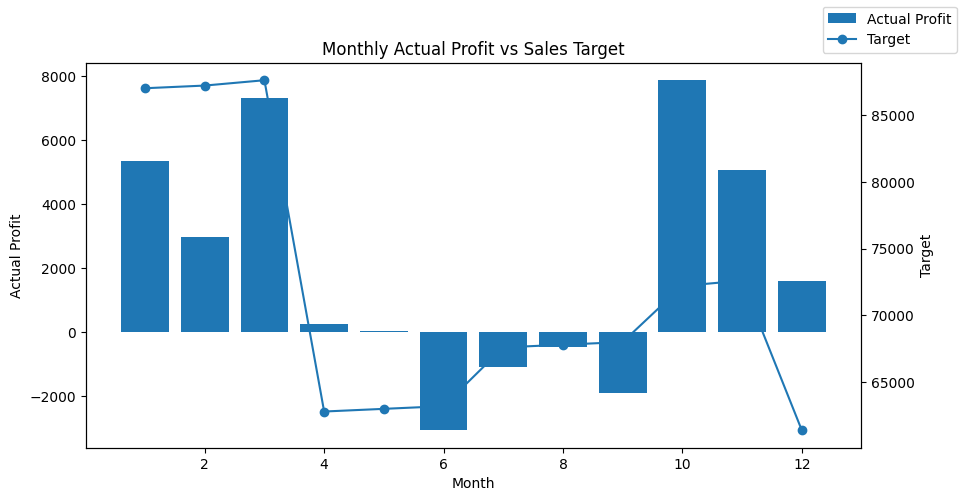

In [129]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Bar chart (Actual Profit)
ax1.bar(monthly_summary['Month'], monthly_summary['Profit'], label='Actual Profit')
ax1.set_xlabel("Month")
ax1.set_ylabel("Actual Profit")

# Line chart (Target)
ax2 = ax1.twinx()
ax2.plot(monthly_summary['Month'], monthly_summary['Target'], marker='o', label='Target')
ax2.set_ylabel("Target")

plt.title("Monthly Actual Profit vs Sales Target")

fig.legend(loc="upper right")

plt.show()

### 📊 Sales Target Analysis Insights

- The actual profit is significantly lower than the sales targets across all months.
- None of the months achieved the defined sales targets, indicating a large performance gap.
- Negative profit values in months 6 to 9 indicate periods of financial loss.
- Profit shows improvement in months 10 and 11, suggesting possible recovery or increased sales.
- However, the decline in month 12 indicates inconsistency in performance.
- Overall, the business is not meeting its targets and requires strategic improvements in sales and operations.

##  Correlation Analysis

Understanding relationships between key variables.

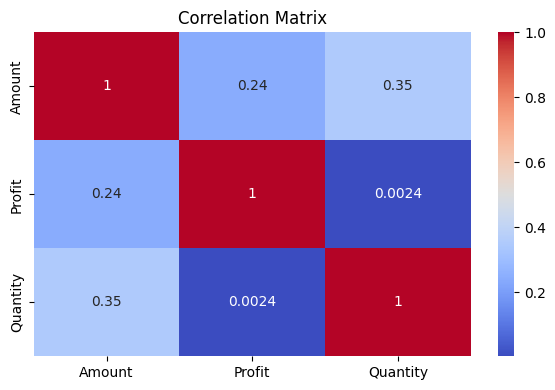

In [130]:
corr_matrix = merged_df[['Amount','Profit','Quantity']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 💡 Insight:
- Strong positive correlation between Amount and Profit
- Quantity may not always strongly influence profit
- Pricing and margin strategies play a key role in profitability

## 🧾 Conclusion

- Business performance varies across months and regions  
- High-value customers contribute significantly to total profit  
- Certain product categories dominate revenue generation  
- Not all sales targets are achieved consistently  
- Data-driven decision-making can improve overall business performance  